In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [3]:
df = pd.read_csv("credit_dataset_5000_enhanced_final.csv")

In [4]:
print(df.head())

   Age  Income  Coapplicant_Income  Dependents  Employ_Status   Debt  \
0   61   26587               10296           1       Employed  56824   
1   36   23236               13264           3  Self-employed  78620   
2   66   19245               32648           5       Employed  34596   
3   29   64148               19563           1       Employed  59612   
4   43  101424               49221           1     Unemployed   1523   

   PrevLDefault  CIBIL_Score  Loan_Approval  
0             1          465              0  
1             1          456              1  
2             0          572              0  
3             0          620              0  
4             0          659              0  


In [5]:
df['Employ_Status'].unique()

array(['Employed', 'Self-employed', 'Unemployed'], dtype=object)

In [6]:
df.isnull().sum()

Age                   0
Income                0
Coapplicant_Income    0
Dependents            0
Employ_Status         0
Debt                  0
PrevLDefault          0
CIBIL_Score           0
Loan_Approval         0
dtype: int64

In [7]:
df['PrevLDefault'].unique()

array([1, 0])

In [8]:
(df['Loan_Approval'] == 0).sum()

np.int64(2504)

In [9]:
(df['Loan_Approval'] == 1).sum()

np.int64(2496)

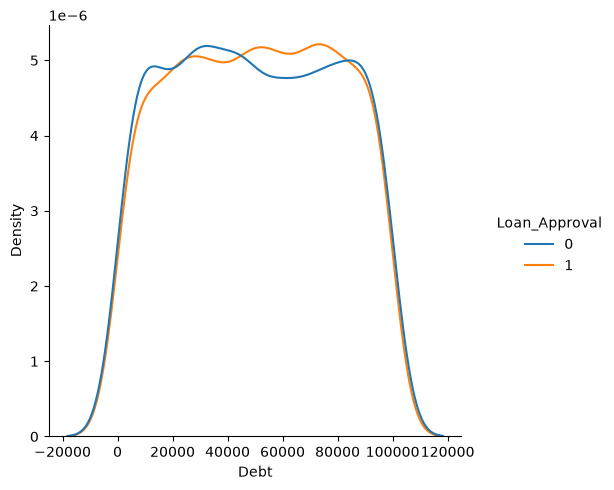

In [10]:
sns.displot(
    data=df,
    x="Debt",
    hue="Loan_Approval",
    kind="kde"
)


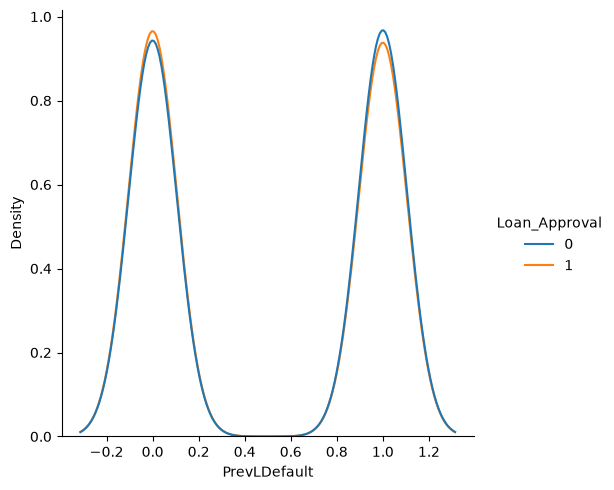

In [11]:
sns.displot(
    data=df,
    x="PrevLDefault",
    hue="Loan_Approval",
    kind="kde"
)

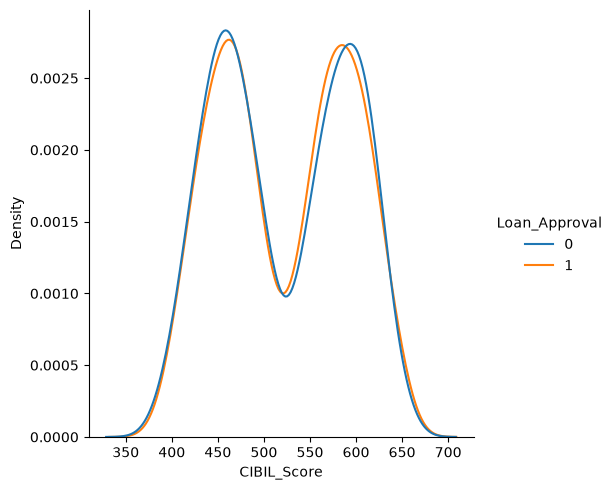

In [12]:
sns.displot(
    data=df,
    x="CIBIL_Score",
    hue="Loan_Approval",
    kind="kde"
)

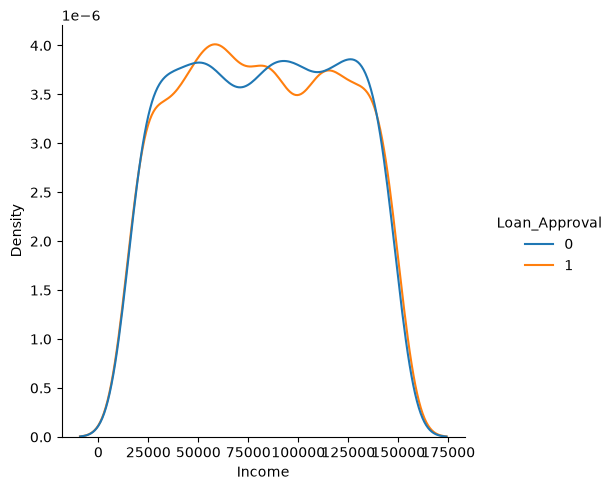

In [13]:
sns.displot(
    data=df,
    x="Income",
    hue="Loan_Approval",
    kind="kde"
)

<Axes: xlabel='Loan_Approval', ylabel='CIBIL_Score'>

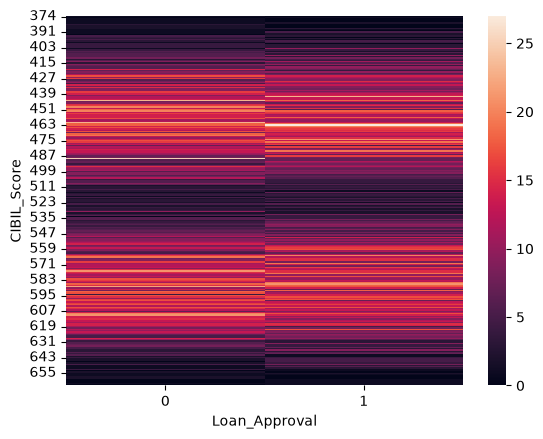

In [14]:
sns.heatmap(pd.crosstab(df['CIBIL_Score'],df['Loan_Approval']))

In [15]:
pd.crosstab(df['PrevLDefault'], df['Loan_Approval'])

Loan_Approval,0,1
PrevLDefault,,
0,1236,1266
1,1268,1230


In [16]:
df

,Age,Income,Coapplicant_Income,Dependents,Employ_Status,Debt,PrevLDefault,CIBIL_Score,Loan_Approval
0,61,26587,10296,1,Employed,56824,1,465,0
1,36,23236,13264,3,Self-employed,78620,1,456,1
2,66,19245,32648,5,Employed,34596,0,572,0
3,29,64148,19563,1,Employed,59612,0,620,0
4,43,101424,49221,1,Unemployed,1523,0,659,0
...,...,...,...,...,...,...,...,...,...
4995,33,76196,76786,3,Self-employed,80218,1,445,0
4996,32,93373,5342,0,Self-employed,78488,1,471,1
4997,57,21445,25752,4,Unemployed,27510,1,481,0
4998,58,34367,47047,3,Unemployed,2577,1,476,1


In [17]:
np.random.seed(42)

In [18]:
score = (
    (df['CIBIL_Score'] - df['CIBIL_Score'].mean()) / df['CIBIL_Score'].std() * 2.5
    - df['PrevLDefault'] * 0.0          # removed - it's ~-0.91 correlated with CIBIL_Score already
    - (df['Debt'] / df['Income'].replace(0, np.nan).fillna(df['Income'].mean())) * 0.8
    + (df['Income'] - df['Income'].mean()) / df['Income'].std() * 1.3
    - df['Dependents'] * 0.1
    + np.where(df['Employ_Status'] == 'Employed', 2.0,
        np.where(df['Employ_Status'] == 'Self-employed', 2.2, -2.0))
)


In [19]:
threshold = score.median()
df['Loan_Approval'] = (score > threshold).astype(int)

print(df['Loan_Approval'].value_counts(normalize=True))

Loan_Approval
0    0.5
1    0.5
Name: proportion, dtype: float64


In [20]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Loan_Approval']),df['Loan_Approval'],
                                                test_size=0.2,random_state=42)

In [21]:
X_train

,Age,Income,Coapplicant_Income,Dependents,Employ_Status,Debt,PrevLDefault,CIBIL_Score
4227,46,59919,66406,4,Self-employed,6322,1,448
4676,38,148339,1214,1,Self-employed,44037,0,569
800,65,86447,10673,2,Employed,2395,0,613
3671,68,99438,85982,4,Unemployed,67552,1,440
4193,50,65202,79154,4,Unemployed,27458,1,427
...,...,...,...,...,...,...,...,...
4426,65,86874,74766,3,Unemployed,1521,1,447
466,37,103570,42480,0,Unemployed,75027,1,467
3092,26,56099,55221,1,Employed,33205,1,487
3772,35,146002,16101,3,Unemployed,73533,0,580


In [22]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [23]:
trf1 = ColumnTransformer([
    ('employ_status',
     OrdinalEncoder(categories=[['Unemployed', 'Employed', 'Self-employed']],
                     handle_unknown='use_encoded_value',
                     unknown_value=-1),
     [4])
], remainder='passthrough')

result = trf1.fit_transform(X_train)
result1=trf1.fit_transform(X_test)
Employment_train = pd.DataFrame(result, columns=trf1.get_feature_names_out())
Employment_test = pd.DataFrame(result1,columns=trf1.get_feature_names_out())
print(Employment_train)

      employ_status__Employ_Status  remainder__Age  remainder__Income  \
0                              2.0            46.0            59919.0   
1                              2.0            38.0           148339.0   
2                              1.0            65.0            86447.0   
3                              0.0            68.0            99438.0   
4                              0.0            50.0            65202.0   
...                            ...             ...                ...   
3995                           0.0            65.0            86874.0   
3996                           0.0            37.0           103570.0   
3997                           1.0            26.0            56099.0   
3998                           0.0            35.0           146002.0   
3999                           1.0            53.0            47700.0   

      remainder__Coapplicant_Income  remainder__Dependents  remainder__Debt  \
0                           66406.0         

In [24]:
Employment_train.columns = [col.replace("remainder__", "").replace("employ_status__", "") 
                            for col in Employment_train.columns]
Employment_test.columns = [col.replace("remainder__", "").replace("employ_status__", "") 
                           for col in Employment_test.columns]

In [25]:
Employment_train

,Employ_Status,Age,Income,Coapplicant_Income,Dependents,Debt,PrevLDefault,CIBIL_Score
0,2.0,46.0,59919.0,66406.0,4.0,6322.0,1.0,448.0
1,2.0,38.0,148339.0,1214.0,1.0,44037.0,0.0,569.0
2,1.0,65.0,86447.0,10673.0,2.0,2395.0,0.0,613.0
3,0.0,68.0,99438.0,85982.0,4.0,67552.0,1.0,440.0
4,0.0,50.0,65202.0,79154.0,4.0,27458.0,1.0,427.0
...,...,...,...,...,...,...,...,...
3995,0.0,65.0,86874.0,74766.0,3.0,1521.0,1.0,447.0
3996,0.0,37.0,103570.0,42480.0,0.0,75027.0,1.0,467.0
3997,1.0,26.0,56099.0,55221.0,1.0,33205.0,1.0,487.0
3998,0.0,35.0,146002.0,16101.0,3.0,73533.0,0.0,580.0


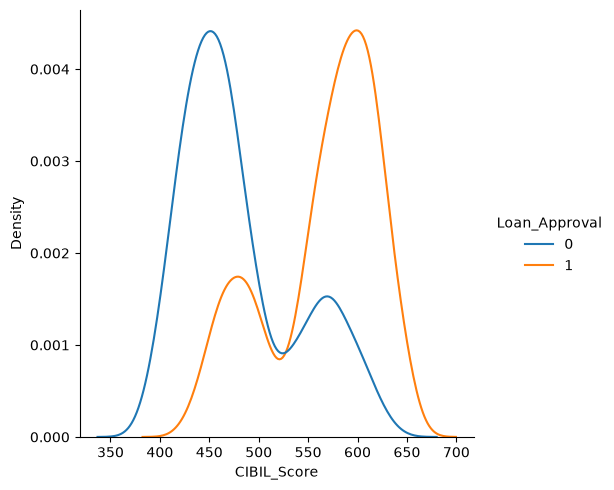

In [26]:
sns.displot(
    data=df,
    x="CIBIL_Score",
    hue="Loan_Approval",
    kind="kde"
)

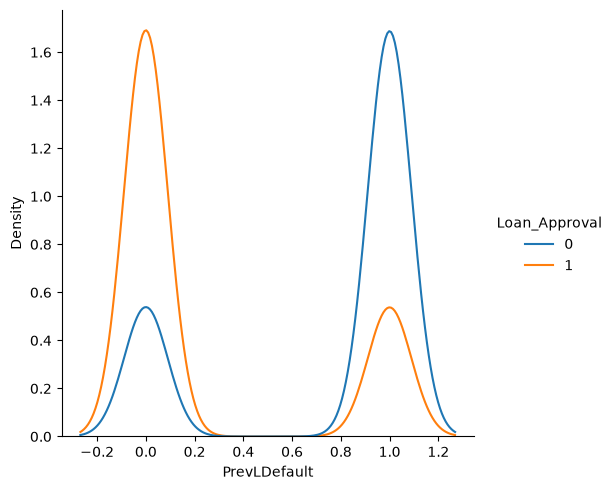

In [27]:
sns.displot(
    data=df,
    x="PrevLDefault",
    hue="Loan_Approval",
    kind="kde"
)

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=6,           
    min_samples_leaf=10,
    random_state=42
)
rf_model.fit(Employment_train, y_train)
y_pred = rf_model.predict(Employment_test)
print('Train accuracy:', accuracy_score(y_train, rf_model.predict(Employment_train)))
print('Test accuracy :', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Train accuracy: 0.97525
Test accuracy : 0.967

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       507
           1       0.97      0.96      0.97       493

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [29]:
print("Accuracy",accuracy_score(y_test,y_pred)*100)

Accuracy 96.7


In [30]:
from sklearn.model_selection import cross_val_score
model = RandomForestClassifier()
print("Training",np.mean(cross_val_score(model,Employment_train,y_train,scoring='accuracy',cv=10))*100)
print("Testing",np.mean(cross_val_score(model,Employment_test,y_test,scoring='accuracy',cv=10))*100)

Training 97.7
Testing 97.00000000000001


In [31]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=Employment_train.columns
).sort_values(ascending=False)

print(importances)

CIBIL_Score           0.328210
Income                0.226467
Employ_Status         0.206884
PrevLDefault          0.170420
Debt                  0.027800
Dependents            0.023862
Coapplicant_Income    0.009174
Age                   0.007183
dtype: float64
